[sigma_d=0.000] P_base=2.533464e+01 | P_direct=1.747526e+01 | P_pre=1.725575e+01 | offdiag_direct=0.9546 | offdiag_pre=0.9542
[sigma_d=0.050] P_base=2.533464e+01 | P_direct=1.578588e+01 | P_pre=1.487589e+01 | offdiag_direct=0.8294 | offdiag_pre=0.8196
[sigma_d=0.100] P_base=2.533464e+01 | P_direct=1.181997e+01 | P_pre=1.117153e+01 | offdiag_direct=0.6361 | offdiag_pre=0.6700
[sigma_d=0.200] P_base=2.533464e+01 | P_direct=5.861843e+00 | P_pre=5.631396e+00 | offdiag_direct=0.7378 | offdiag_pre=0.7492


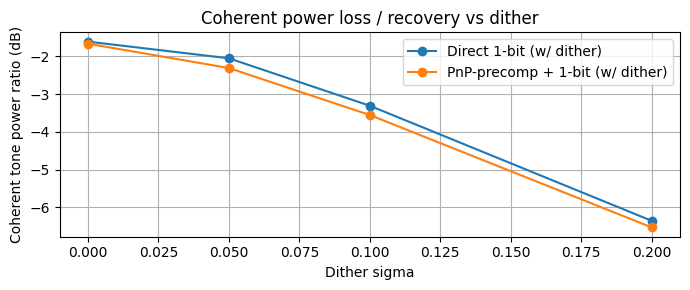

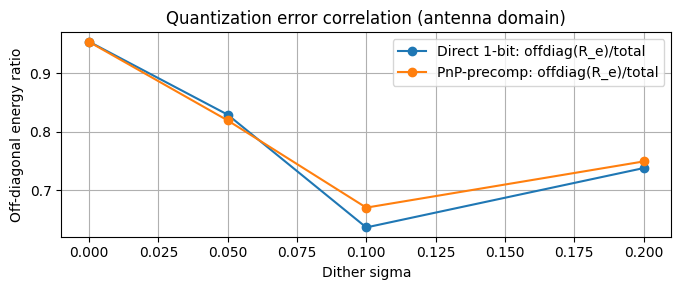

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import numpy as np
import matplotlib.pyplot as plt

# ================= USER CONFIG =================
N = 45
FS = 250_000  # 250 kHz baseband sampling rate (used only if you later add CFO / tone at nonzero f0)
T = 8192      # number of baseband samples in one frame/block (you can change)

# Dither sweep (you can tune)
DITHER_SIGMA_LIST = [0.0, 0.05, 0.1, 0.2]

# PnP-PGD params
K_ITERS = 30          # number of iterations
MU = 0.5              # gradient step size (tune)
BETA = 3.0            # smooth-quantizer steepness (bigger -> closer to sign)
CBD_RANK = 1          # rank-1 CBD denoiser for single-user (keep 1 for now)

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Input CSI (MRT uses h)
# Option A: load from file (recommended for real CSI)
#   - store as complex64 length N: h.bin
H_PATH = "h.bin"  # change if needed

# ================= UTILITIES =================
def load_h(path: str, N: int) -> np.ndarray:
    """
    Load channel vector h (N,) complex64 from binary file.
    If file not found, generate a random Rayleigh channel for a quick sanity check.
    """
    if os.path.exists(path):
        h = np.fromfile(path, dtype=np.complex64)
        if h.size != N:
            raise ValueError(f"h size mismatch: expected {N}, got {h.size}")
        return h.astype(np.complex128)
    else:
        # quick fallback: Rayleigh fading
        h = (rng.standard_normal(N) + 1j * rng.standard_normal(N)) / np.sqrt(2)
        return h.astype(np.complex128)

def mrt_precoder(h: np.ndarray) -> np.ndarray:
    """
    MRT: w = conj(h)/||h||
    """
    denom = np.linalg.norm(h)
    if denom < 1e-12:
        raise ValueError("||h|| is too small.")
    return np.conj(h) / denom

def normalize_total_power(X: np.ndarray, target_power: float = 1.0) -> np.ndarray:
    """
    Normalize average total power across antennas:
      mean_t ||x[t]||^2 = target_power
    X shape: (N, T)
    """
    p = np.mean(np.sum(np.abs(X)**2, axis=0))
    if p < 1e-15:
        return X
    return X * np.sqrt(target_power / p)

def q1bit_hard(z: np.ndarray) -> np.ndarray:
    """
    Hard 1-bit quantization on I/Q: sign(Re)+j sign(Im), normalized by 1/sqrt(2)
    z shape: (N, T)
    """
    re = np.where(z.real >= 0, 1.0, -1.0)
    im = np.where(z.imag >= 0, 1.0, -1.0)
    return (re + 1j * im) / np.sqrt(2)

def q1bit_soft(z: np.ndarray, beta: float) -> np.ndarray:
    """
    Soft differentiable approximation of 1-bit quantization using tanh.
    Useful for gradient-based optimization.
    """
    re = np.tanh(beta * z.real)
    im = np.tanh(beta * z.imag)
    return (re + 1j * im) / np.sqrt(2)

def cbd_rank1_denoiser(X: np.ndarray, rank: int = 1) -> np.ndarray:
    """
    Compression-based denoiser (CBD) prototype:
      rank-1 (or low-rank) projection across antenna x time matrix.
    For single-user tone-like waveforms, rank-1 is a strong structural prior.
    """
    # SVD on complex matrix: use np.linalg.svd (works for complex)
    U, S, Vh = np.linalg.svd(X, full_matrices=False)
    r = int(rank)
    r = max(1, min(r, S.size))
    Xr = (U[:, :r] * S[:r]) @ Vh[:r, :]
    return Xr

def coherent_tone_power(h: np.ndarray, Xq: np.ndarray) -> float:
    """
    For a pure tone (constant symbol), y[t] = h^T x_q[t].
    Effective coherent tone component is mean(y[t]) (DC in baseband).
    P_coh = |mean(y)|^2
    """
    y = h.T @ Xq  # (T,)
    a = np.mean(y)
    return float(np.abs(a)**2)

def error_corr_offdiag_energy(E: np.ndarray) -> float:
    """
    Quantization error correlation matrix:
      R_e = (1/T) sum_t e[t] e[t]^H
    Return the ratio of off-diagonal energy to total energy:
      offdiag_energy / total_energy
    """
    # R_e: (N,N)
    Re = (E @ E.conj().T) / E.shape[1]
    total = np.sum(np.abs(Re)**2)
    diag = np.sum(np.abs(np.diag(Re))**2)
    off = total - diag
    if total < 1e-15:
        return 0.0
    return float(off / total)

# ================= PnP-PGD PRECOMP =================
def pnp_precomp_singleuser(
    h: np.ndarray,
    X_init: np.ndarray,
    dither_sigma: float,
    k_iters: int,
    mu: float,
    beta: float,
    cbd_rank: int = 1,
    target_power: float = 1.0,
) -> np.ndarray:
    """
    PnP-PGD precompensation:
      - data step: gradient ascent on |h^T Q_soft(x + d)|^2
      - prior step: CBD denoiser (rank-1 projection)
    Returns precompensated X (before hard quantization).
    """
    N, T = X_init.shape
    X = X_init.copy()

    # fixed dither sequence per run (you can also regenerate each iter; fixed is fine for stable optimization)
    D = (rng.standard_normal((N, T)) + 1j * rng.standard_normal((N, T))) * (dither_sigma / np.sqrt(2))

    # Precompute repeated h
    h_col = h.reshape(N, 1)

    for _ in range(k_iters):
        Z = X + D
        Xq_soft = q1bit_soft(Z, beta=beta)  # (N,T)

        # y = h^T Xq
        y = (h.T @ Xq_soft)  # (T,)

        # Objective: J = |mean(y)|^2, where a = mean(y)
        a = np.mean(y)  # complex scalar
        # gradient of J wrt y is: dJ/dy[t] = (1/T) * a*  (for y) and conj depending on convention
        # We'll implement a practical gradient on Z through soft quantizer derivative:
        #
        # Xq_soft = (tanh(beta Re)+j tanh(beta Im))/sqrt(2)
        # dXq/dRe = beta * sech^2(beta Re) / sqrt(2)
        # dXq/dIm = j * beta * sech^2(beta Im) / sqrt(2)

        # dy/dXq = h (since y[t] = sum_i h_i Xq_i[t])
        # gradient ascent step: push Xq to align with conj(h)*conj(a) direction coherently

        # weights over time from "a"
        # Using a simple surrogate: maximize Re{ conj(a) * y[t] } summed -> aligns y with a
        w_t = np.conj(a) / T  # scalar

        # derivative factors
        sech2_re = 1.0 - np.tanh(beta * Z.real)**2
        sech2_im = 1.0 - np.tanh(beta * Z.imag)**2
        dXq_dRe = (beta * sech2_re) / np.sqrt(2)
        dXq_dIm = (1j * beta * sech2_im) / np.sqrt(2)

        # gradient of Re{ conj(a)*y[t] } w.r.t Xq is conj(a)*h
        # distribute across time
        gXq = (h_col * w_t)  # (N,1), broadcast over T

        # chain rule to Z (treat Re and Im separately)
        gZ = gXq * dXq_dRe + gXq * dXq_dIm  # (N,T)

        # gradient ascent
        X = X + mu * gZ

        # CBD prior / denoise step
        X = cbd_rank1_denoiser(X, rank=cbd_rank)

        # power normalize (fair comparison)
        X = normalize_total_power(X, target_power=target_power)

    return X

# ================= MAIN EXPERIMENT =================
def run():
    h = load_h(H_PATH, N)
    w = mrt_precoder(h)

    # Single-user tone in baseband: s[t]=1
    s = np.ones(T, dtype=np.complex128)

    # Ideal (unquantized) precoded waveform: X = w s^T
    X_ideal = w.reshape(N, 1) @ s.reshape(1, T)
    X_ideal = normalize_total_power(X_ideal, target_power=1.0)

    # Baseline coherent power (no quantization)
    P_base = coherent_tone_power(h, X_ideal)

    results = []

    for sigma_d in DITHER_SIGMA_LIST:
        # Direct 1-bit (with optional dither)
        D = (rng.standard_normal((N, T)) + 1j * rng.standard_normal((N, T))) * (sigma_d / np.sqrt(2))
        Xq_direct = q1bit_hard(X_ideal + D)
        Xq_direct = normalize_total_power(Xq_direct, target_power=1.0)

        P_direct = coherent_tone_power(h, Xq_direct)
        E_direct = Xq_direct - X_ideal
        offdiag_direct = error_corr_offdiag_energy(E_direct)

        # PnP precomp + hard 1-bit
        X_pre = pnp_precomp_singleuser(
            h=h,
            X_init=X_ideal,
            dither_sigma=sigma_d,
            k_iters=K_ITERS,
            mu=MU,
            beta=BETA,
            cbd_rank=CBD_RANK,
            target_power=1.0,
        )
        Xq_pre = q1bit_hard(X_pre + D)  # reuse D for fairness (or regenerate; either is ok)
        Xq_pre = normalize_total_power(Xq_pre, target_power=1.0)

        P_pre = coherent_tone_power(h, Xq_pre)
        E_pre = Xq_pre - X_ideal
        offdiag_pre = error_corr_offdiag_energy(E_pre)

        results.append((sigma_d, P_base, P_direct, P_pre, offdiag_direct, offdiag_pre))

        print(f"[sigma_d={sigma_d:.3f}] "
              f"P_base={P_base:.6e} | P_direct={P_direct:.6e} | P_pre={P_pre:.6e} | "
              f"offdiag_direct={offdiag_direct:.4f} | offdiag_pre={offdiag_pre:.4f}")

    # Plot coherent power ratio (dB)
    sigmas = np.array([r[0] for r in results])
    Pdirect = np.array([r[2] for r in results])
    Ppre = np.array([r[3] for r in results])

    # avoid log of 0
    eps = 1e-20
    gain_direct_db = 10 * np.log10((Pdirect + eps) / (P_base + eps))
    gain_pre_db = 10 * np.log10((Ppre + eps) / (P_base + eps))

    plt.figure(figsize=(7, 3))
    plt.plot(sigmas, gain_direct_db, marker="o", label="Direct 1-bit (w/ dither)")
    plt.plot(sigmas, gain_pre_db, marker="o", label="PnP-precomp + 1-bit (w/ dither)")
    plt.xlabel("Dither sigma")
    plt.ylabel("Coherent tone power ratio (dB)")
    plt.title("Coherent power loss / recovery vs dither")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot off-diagonal correlation energy ratio
    off_direct = np.array([r[4] for r in results])
    off_pre = np.array([r[5] for r in results])

    plt.figure(figsize=(7, 3))
    plt.plot(sigmas, off_direct, marker="o", label="Direct 1-bit: offdiag(R_e)/total")
    plt.plot(sigmas, off_pre, marker="o", label="PnP-precomp: offdiag(R_e)/total")
    plt.xlabel("Dither sigma")
    plt.ylabel("Off-diagonal energy ratio")
    plt.title("Quantization error correlation (antenna domain)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run()


=== Coherent carrier power (tone) ===
Baseline (no quant): P0 = 2.533464e+01
sigma_d    P1bit         loss(dB)
  0.000  1.747526e+01    -1.613
  0.020  1.717382e+01    -1.688
  0.050  1.580251e+01    -2.050
  0.100  1.184040e+01    -3.303
  0.200  5.882894e+00    -6.341


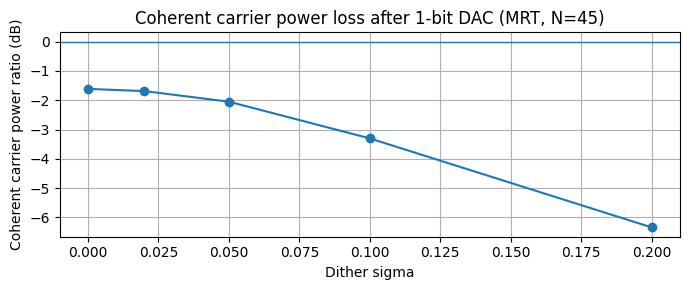

In [2]:
# --- Cell: Single-user MRT tone, coherent carrier power loss after 1-bit DAC ---

import numpy as np
import matplotlib.pyplot as plt

# ============ Config ============
N = 45                 # antennas
T = 20000              # samples (tone duration)
rng = np.random.default_rng(42)

# Optional dither sweep (set to [0.0] if you want no dither)
dither_sigma_list = [0.0, 0.02, 0.05, 0.1, 0.2]

# ============ Helpers ============
def mrt_precoder(h: np.ndarray) -> np.ndarray:
    return np.conj(h) / np.linalg.norm(h)

def normalize_total_power(X: np.ndarray, target_power: float = 1.0) -> np.ndarray:
    # mean_t ||x[t]||^2 = target_power
    p = np.mean(np.sum(np.abs(X)**2, axis=0))
    return X if p < 1e-15 else X * np.sqrt(target_power / p)

def q1bit(z: np.ndarray) -> np.ndarray:
    # 1-bit on I and Q, constant modulus, normalized to unit power per complex symbol
    re = np.where(z.real >= 0, 1.0, -1.0)
    im = np.where(z.imag >= 0, 1.0, -1.0)
    return (re + 1j * im) / np.sqrt(2)

def coherent_tone_power(h: np.ndarray, X: np.ndarray) -> float:
    # y[t] = h^T x[t], coherent carrier (DC in baseband tone) is mean(y)
    y = h.T @ X  # (T,)
    a = np.mean(y)
    return float(np.abs(a)**2)

# ============ Channel + Tone ============
# Rayleigh channel (replace with your measured h if you want)
h = (rng.standard_normal(N) + 1j * rng.standard_normal(N)) / np.sqrt(2)
w = mrt_precoder(h)

# Baseband "carrier only" => s[t]=1 (DC tone in baseband)
s = np.ones(T, dtype=np.complex128)

# Unquantized MRT precoded waveform
X0 = w.reshape(N, 1) @ s.reshape(1, T)
X0 = normalize_total_power(X0, target_power=1.0)

P0 = coherent_tone_power(h, X0)

# ============ 1-bit results ============
rows = []
for sigma_d in dither_sigma_list:
    D = (rng.standard_normal((N, T)) + 1j * rng.standard_normal((N, T))) * (sigma_d / np.sqrt(2))
    Xq = q1bit(X0 + D)
    Xq = normalize_total_power(Xq, target_power=1.0)

    Pq = coherent_tone_power(h, Xq)
    loss_db = 10 * np.log10((Pq + 1e-20) / (P0 + 1e-20))
    rows.append((sigma_d, P0, Pq, loss_db))

# Print table
print("=== Coherent carrier power (tone) ===")
print(f"Baseline (no quant): P0 = {P0:.6e}")
print("sigma_d    P1bit         loss(dB)")
for sigma_d, _, Pq, loss_db in rows:
    print(f"{sigma_d:7.3f}  {Pq:.6e}  {loss_db:8.3f}")

# Plot loss vs dither
sigmas = np.array([r[0] for r in rows], dtype=float)
loss_db = np.array([r[3] for r in rows], dtype=float)

plt.figure(figsize=(7, 3))
plt.plot(sigmas, loss_db, marker="o")
plt.axhline(0.0, linewidth=1)
plt.grid(True)
plt.xlabel("Dither sigma")
plt.ylabel("Coherent carrier power ratio (dB)")
plt.title("Coherent carrier power loss after 1-bit DAC (MRT, N=45)")
plt.tight_layout()
plt.show()


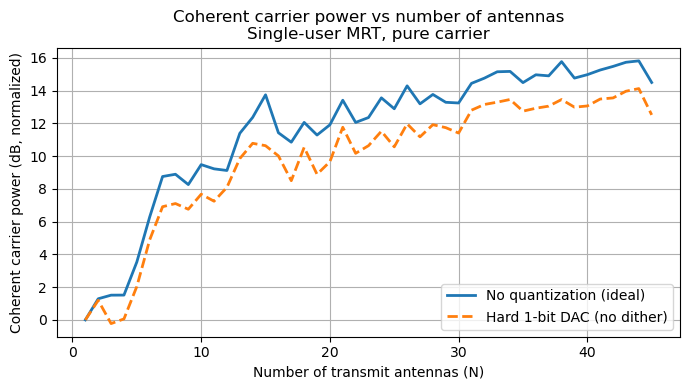

In [1]:
# --- Cell: Coherent carrier power vs number of antennas (No quantization vs Hard 1-bit) ---

import numpy as np
import matplotlib.pyplot as plt

# ============ Config ============
rng = np.random.default_rng(40)

T = 20000                  # samples per tone burst
N_list = np.arange(1, 46)  # sweep number of antennas: 1 ... 45

# ============ Helpers ============
def mrt_precoder(h: np.ndarray) -> np.ndarray:
    return np.conj(h) / np.linalg.norm(h)

def normalize_total_power(X: np.ndarray, target_power: float = 1.0) -> np.ndarray:
    p = np.mean(np.sum(np.abs(X)**2, axis=0))
    return X if p < 1e-15 else X * np.sqrt(target_power / p)

def q1bit(z: np.ndarray) -> np.ndarray:
    re = np.where(z.real >= 0, 1.0, -1.0)
    im = np.where(z.imag >= 0, 1.0, -1.0)
    return (re + 1j * im) / np.sqrt(2)

def coherent_tone_power(h: np.ndarray, X: np.ndarray) -> float:
    y = h.T @ X
    return float(np.abs(np.mean(y))**2)

# ============ Simulation ============
P_no_quant = []
P_1bit = []

for N in N_list:
    # Rayleigh channel
    h = (rng.standard_normal(N) + 1j * rng.standard_normal(N)) / np.sqrt(2)

    # MRT precoder
    w = mrt_precoder(h)

    # Baseband carrier: s[t] = 1
    s = np.ones(T, dtype=np.complex128)

    # Ideal precoded waveform
    X0 = w.reshape(N, 1) @ s.reshape(1, T)
    X0 = normalize_total_power(X0, target_power=1.0)

    # No quantization
    P0 = coherent_tone_power(h, X0)

    # Hard 1-bit quantization (NO dither)
    Xq = q1bit(X0)
    Xq = normalize_total_power(Xq, target_power=1.0)
    Pq = coherent_tone_power(h, Xq)

    P_no_quant.append(P0)
    P_1bit.append(Pq)

P_no_quant = np.array(P_no_quant)
P_1bit = np.array(P_1bit)

# Convert to dB (relative to single-antenna unquantized power)
ref = P_no_quant[0]
P_no_quant_db = 10 * np.log10(P_no_quant / ref)
P_1bit_db = 10 * np.log10(P_1bit / ref)

# ============ Plot ============
plt.figure(figsize=(7, 4))
plt.plot(N_list, P_no_quant_db, linewidth=2, label="No quantization (ideal)")
plt.plot(N_list, P_1bit_db, linewidth=2, linestyle="--", label="Hard 1-bit DAC (no dither)")
plt.grid(True)
plt.xlabel("Number of transmit antennas (N)")
plt.ylabel("Coherent carrier power (dB, normalized)")
plt.title("Coherent carrier power vs number of antennas\nSingle-user MRT, pure carrier")
plt.legend()
plt.tight_layout()
plt.show()


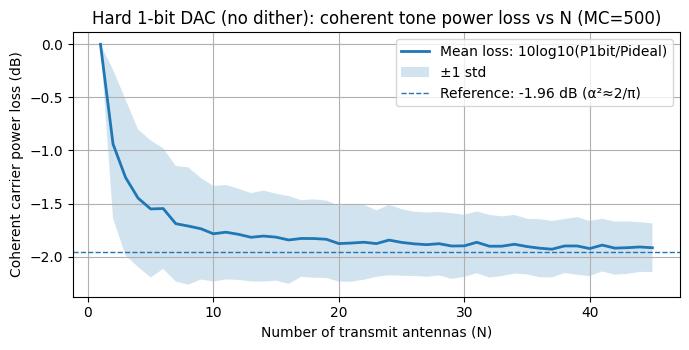

In [7]:
# --- Cell: Loss(dB) of coherent carrier power after hard 1-bit (NO dither), averaged over channels ---

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

T = 20000
N_list = np.arange(1, 46)
MC = 500  # Monte-Carlo trials per N (increase if you want smoother)

def mrt_precoder(h: np.ndarray) -> np.ndarray:
    return np.conj(h) / np.linalg.norm(h)

def normalize_total_power(X: np.ndarray, target_power: float = 1.0) -> np.ndarray:
    p = np.mean(np.sum(np.abs(X)**2, axis=0))
    return X if p < 1e-15 else X * np.sqrt(target_power / p)

def q1bit(z: np.ndarray) -> np.ndarray:
    re = np.where(z.real >= 0, 1.0, -1.0)
    im = np.where(z.imag >= 0, 1.0, -1.0)
    return (re + 1j * im) / np.sqrt(2)

def coherent_tone_power(h: np.ndarray, X: np.ndarray) -> float:
    y = h.T @ X
    return float(np.abs(np.mean(y))**2)

loss_mean = []
loss_std = []

s = np.ones(T, dtype=np.complex128)

for N in N_list:
    losses = []
    for _ in range(MC):
        h = (rng.standard_normal(N) + 1j * rng.standard_normal(N)) / np.sqrt(2)
        w = mrt_precoder(h)

        X0 = w.reshape(N, 1) @ s.reshape(1, T)
        X0 = normalize_total_power(X0, 1.0)
        P0 = coherent_tone_power(h, X0)

        Xq = q1bit(X0)                       # NO dither
        Xq = normalize_total_power(Xq, 1.0)
        P1 = coherent_tone_power(h, Xq)

        losses.append(10*np.log10((P1 + 1e-20) / (P0 + 1e-20)))

    losses = np.array(losses)
    loss_mean.append(losses.mean())
    loss_std.append(losses.std())

loss_mean = np.array(loss_mean)
loss_std = np.array(loss_std)

plt.figure(figsize=(7, 3.6))
plt.plot(N_list, loss_mean, linewidth=2, label="Mean loss: 10log10(P1bit/Pideal)")
plt.fill_between(N_list, loss_mean - loss_std, loss_mean + loss_std, alpha=0.2, label="±1 std")
plt.axhline(-1.96, linestyle="--", linewidth=1, label="Reference: -1.96 dB (α²≈2/π)")
plt.grid(True)
plt.xlabel("Number of transmit antennas (N)")
plt.ylabel("Coherent carrier power loss (dB)")
plt.title(f"Hard 1-bit DAC (no dither): coherent tone power loss vs N (MC={MC})")
plt.legend()
plt.tight_layout()
plt.show()


Ptx= -50 dB | BER ideal=4.370e-01 | BER 1-bit+dither=4.635e-01
Ptx= -48 dB | BER ideal=4.215e-01 | BER 1-bit+dither=4.547e-01
Ptx= -46 dB | BER ideal=3.991e-01 | BER 1-bit+dither=4.410e-01
Ptx= -44 dB | BER ideal=3.766e-01 | BER 1-bit+dither=4.279e-01
Ptx= -42 dB | BER ideal=3.446e-01 | BER 1-bit+dither=4.081e-01
Ptx= -40 dB | BER ideal=3.067e-01 | BER 1-bit+dither=3.847e-01
Ptx= -38 dB | BER ideal=2.632e-01 | BER 1-bit+dither=3.571e-01
Ptx= -36 dB | BER ideal=2.124e-01 | BER 1-bit+dither=3.226e-01
Ptx= -34 dB | BER ideal=1.579e-01 | BER 1-bit+dither=2.822e-01
Ptx= -32 dB | BER ideal=1.027e-01 | BER 1-bit+dither=2.339e-01
Ptx= -30 dB | BER ideal=5.570e-02 | BER 1-bit+dither=1.815e-01
Ptx= -28 dB | BER ideal=2.278e-02 | BER 1-bit+dither=1.272e-01
Ptx= -26 dB | BER ideal=5.752e-03 | BER 1-bit+dither=7.838e-02
Ptx= -24 dB | BER ideal=7.900e-04 | BER 1-bit+dither=4.046e-02
Ptx= -22 dB | BER ideal=3.500e-05 | BER 1-bit+dither=1.597e-02
Ptx= -20 dB | BER ideal=0.000e+00 | BER 1-bit+dither=5.

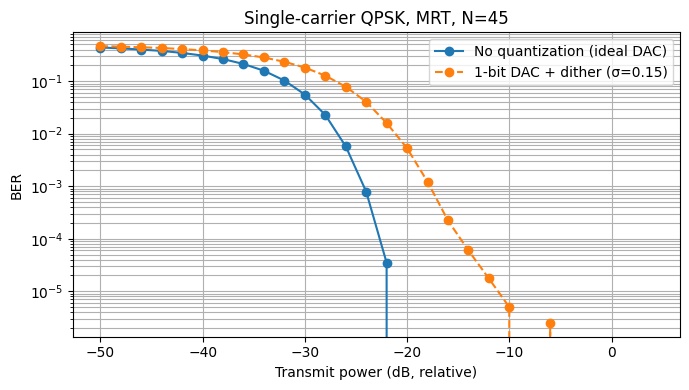

In [13]:
# --- Cell: BER vs Transmit Power (QPSK SC, N=45, MRT)
#            Compare: No quantization vs 1-bit DAC + dither

import numpy as np
import matplotlib.pyplot as plt

# ===================== Config =====================
rng = np.random.default_rng(42)

N = 45
NSYM = 200_000

# Transmit power sweep (relative, in dB)
Ptx_dB_list = np.arange(-50, 6, 2)   # adjust range if needed

# Noise power (FIXED)
NOISE_VAR = 1e-2                     # complex noise variance

# 1-bit + dither
DITHER_SIGMA = 0.15

# ===================== Helpers =====================
def qpsk_mod(bits):
    I = np.where(bits[0::2] == 0, 1.0, -1.0)
    Q = np.where(bits[1::2] == 0, 1.0, -1.0)
    return (I + 1j*Q) / np.sqrt(2)

def qpsk_demod_hard(s):
    bits = np.empty(2*s.size, dtype=np.int8)
    bits[0::2] = (s.real < 0).astype(np.int8)
    bits[1::2] = (s.imag < 0).astype(np.int8)
    return bits

def mrt_precoder(h):
    return np.conj(h) / np.linalg.norm(h)

def q1bit(z):
    re = np.where(z.real >= 0, 1.0, -1.0)
    im = np.where(z.imag >= 0, 1.0, -1.0)
    return (re + 1j*im) / np.sqrt(2)

def estimate_scalar_channel(y, s):
    return np.mean(y * np.conj(s)) / np.mean(np.abs(s)**2)

# ===================== Channel & Data =====================
h = (rng.standard_normal(N) + 1j*rng.standard_normal(N)) / np.sqrt(2)
w = mrt_precoder(h)

bits_tx = rng.integers(0, 2, size=2*NSYM, dtype=np.int8)
s = qpsk_mod(bits_tx)

# Precoded signal (normalized total power = 1)
X = w.reshape(N, 1) * s.reshape(1, NSYM)
X /= np.sqrt(np.mean(np.sum(np.abs(X)**2, axis=0)))

# 1-bit + dither
D = (rng.standard_normal((N, NSYM)) + 1j*rng.standard_normal((N, NSYM))) * (DITHER_SIGMA / np.sqrt(2))
Xq = q1bit(X + D)
Xq /= np.sqrt(np.mean(np.sum(np.abs(Xq)**2, axis=0)))

# Clean received signals (unit TX power)
y0_clean = h.T @ X
yq_clean = h.T @ Xq

# Scalar channel estimates (fixed)
g0 = estimate_scalar_channel(y0_clean, s)
gq = estimate_scalar_channel(yq_clean, s)

# ===================== BER vs TX Power =====================
ber_noquant = []
ber_1bit = []

for Ptx_dB in Ptx_dB_list:
    scale = 10**(Ptx_dB / 20)   # amplitude scaling
    noise = np.sqrt(NOISE_VAR/2) * (rng.standard_normal(NSYM) + 1j*rng.standard_normal(NSYM))

    # No quant
    y0 = scale * y0_clean + noise
    s0_hat = y0 / g0
    bits0_hat = qpsk_demod_hard(s0_hat)
    ber0 = np.mean(bits0_hat != bits_tx)

    # 1-bit + dither
    yq = scale * yq_clean + noise
    sq_hat = yq / gq
    bitsq_hat = qpsk_demod_hard(sq_hat)
    berq = np.mean(bitsq_hat != bits_tx)

    ber_noquant.append(ber0)
    ber_1bit.append(berq)

    print(f"Ptx={Ptx_dB:>4} dB | BER ideal={ber0:.3e} | BER 1-bit+dither={berq:.3e}")

ber_noquant = np.array(ber_noquant)
ber_1bit = np.array(ber_1bit)

# ===================== Plot =====================
plt.figure(figsize=(7, 4))
plt.semilogy(Ptx_dB_list, ber_noquant, marker="o", label="No quantization (ideal DAC)")
plt.semilogy(Ptx_dB_list, ber_1bit, marker="o", linestyle="--", label=f"1-bit DAC + dither (σ={DITHER_SIGMA})")
plt.grid(True, which="both")
plt.xlabel("Transmit power (dB, relative)")
plt.ylabel("BER")
plt.title(f"Single-carrier QPSK, MRT, N={N}")
plt.legend()
plt.tight_layout()
plt.show()


Ptx= -55 dB | BER no-pre=4.700e-01 | BER precomp=4.754e-01
Ptx= -50 dB | BER no-pre=4.487e-01 | BER precomp=4.541e-01
Ptx= -45 dB | BER no-pre=4.076e-01 | BER precomp=4.224e-01
Ptx= -40 dB | BER no-pre=3.381e-01 | BER precomp=3.664e-01
Ptx= -35 dB | BER no-pre=2.293e-01 | BER precomp=2.806e-01
Ptx= -30 dB | BER no-pre=9.364e-02 | BER precomp=1.867e-01
Ptx= -25 dB | BER no-pre=9.625e-03 | BER precomp=1.146e-01
Ptx= -20 dB | BER no-pre=3.333e-05 | BER precomp=4.620e-02
Ptx= -15 dB | BER no-pre=0.000e+00 | BER precomp=4.625e-03
Ptx= -10 dB | BER no-pre=0.000e+00 | BER precomp=1.667e-05


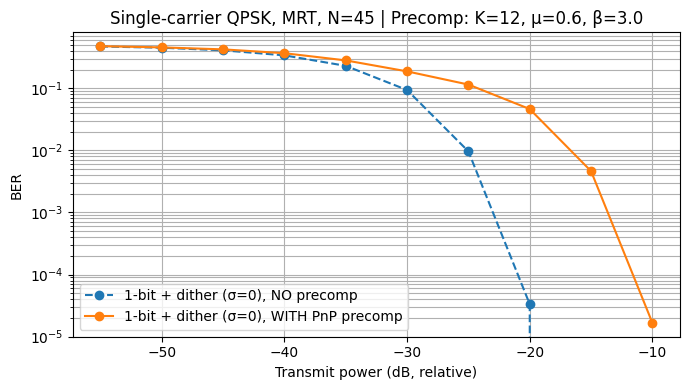

In [15]:
# --- Cell: Single-carrier QPSK BER vs TX power
#           Compare: 1-bit DAC + dither (NO precomp)  vs  1-bit DAC + dither (WITH PnP precomp)
#
# Notes:
# - Flat-fading single-user downlink, N=45, MRT initialization
# - Precompensation uses a light PnP-PGD loop:
#     (A) data step: minimize |h^T Q_soft(x+d) - s|^2 with differentiable tanh quantizer
#     (B) CBD step: rank-1 projection (fast power-iteration form, no full SVD)
# - KPI: BER after scalar equalization
#
# You can tune:
#   - NSYM, Ptx_dB_list range, NOISE_VAR
#   - DITHER_SIGMA
#   - K_ITERS / MU / BETA (precomp strength)

import numpy as np
import matplotlib.pyplot as plt

# ===================== Config =====================
rng = np.random.default_rng(42)

N = 45
NSYM = 60_000                  # keep moderate for runtime; increase for smoother BER
Ptx_dB_list = np.arange(-55, -5, 5)

NOISE_VAR = 1e-2               # fixed complex noise variance
DITHER_SIGMA = 0            # as before

# Precomp params (start here; tune if needed)
USE_PRECOMP = True
K_ITERS = 12
MU = 0.6
BETA = 3.0                     # soft-quant steepness
CBD_POWER_ITERS = 2            # rank-1 projection power iterations per loop

# ===================== Mod/Demod =====================
def qpsk_mod(bits):
    I = np.where(bits[0::2] == 0, 1.0, -1.0)
    Q = np.where(bits[1::2] == 0, 1.0, -1.0)
    return (I + 1j*Q) / np.sqrt(2)

def qpsk_demod_hard(s):
    bits = np.empty(2*s.size, dtype=np.int8)
    bits[0::2] = (s.real < 0).astype(np.int8)
    bits[1::2] = (s.imag < 0).astype(np.int8)
    return bits

# ===================== PHY helpers =====================
def mrt_precoder(h):
    return np.conj(h) / np.linalg.norm(h)

def q1bit_hard(z):
    re = np.where(z.real >= 0, 1.0, -1.0)
    im = np.where(z.imag >= 0, 1.0, -1.0)
    return (re + 1j*im) / np.sqrt(2)

def q1bit_soft(z, beta):
    # differentiable approximation
    re = np.tanh(beta * z.real)
    im = np.tanh(beta * z.imag)
    return (re + 1j*im) / np.sqrt(2)

def normalize_total_power_matrix(X, target_power=1.0):
    # Ensure E[||x[k]||^2] = target_power
    p = np.mean(np.sum(np.abs(X)**2, axis=0))
    return X if p < 1e-15 else X * np.sqrt(target_power / p)

def estimate_scalar_channel(y, s):
    return np.mean(y * np.conj(s)) / np.mean(np.abs(s)**2)

# ===================== Fast rank-1 CBD projection (no full SVD) =====================
def rank1_project_poweriter(X, iters=2):
    """
    Project X onto rank-1 using a few power iterations:
      X ≈ u v^H, u in C^N, v in C^T
    """
    N, T = X.shape
    # init v randomly (or from current)
    v = np.ones(T, dtype=np.complex128)
    v /= np.linalg.norm(v)

    for _ in range(iters):
        u = X @ v.conj()
        nu = np.linalg.norm(u)
        if nu < 1e-15:
            return X
        u /= nu

        v = X.conj().T @ u
        nv = np.linalg.norm(v)
        if nv < 1e-15:
            return X
        v /= nv

    # best rank-1 approx in this subspace
    # scale = u^H X v
    scale = (u.conj().T @ (X @ v.conj()))
    Xr = scale * (u.reshape(N, 1) @ v.conj().reshape(1, T))
    return Xr

# ===================== PnP Precompensation =====================
def pnp_precomp(h, X_init, s, D, k_iters=10, mu=0.5, beta=3.0, cbd_iters=2):
    """
    Minimize sum_k |h^T Q_soft(X+D)[k] - s[k]|^2
    with PnP rank-1 projection prior.
    """
    h = h.astype(np.complex128)
    X = X_init.astype(np.complex128).copy()
    h_col = h.reshape(-1, 1)

    for _ in range(k_iters):
        Z = X + D
        Xq = q1bit_soft(Z, beta=beta)           # (N,T)
        y = (h.T @ Xq)                          # (T,)
        e = (y - s)                              # (T,)

        # Need gradient wrt X (through Z, through tanh)
        # Xq = (tanh(beta ReZ) + j*tanh(beta ImZ))/sqrt(2)
        tanh_re = np.tanh(beta * Z.real)
        tanh_im = np.tanh(beta * Z.imag)
        sech2_re = 1.0 - tanh_re**2
        sech2_im = 1.0 - tanh_im**2

        dXq_dRe = (beta * sech2_re) / np.sqrt(2)
        dXq_dIm = (1j * beta * sech2_im) / np.sqrt(2)

        # d/dXq_i[t] of |y[t]-s[t]|^2 = 2 * conj(h_i) * (y[t]-s[t])
        # (Wirtinger-style practical gradient; works well in practice)
        gXq = (np.conj(h_col) @ e.reshape(1, -1)) * 2.0   # (N,T)

        # Chain to Z (and thus X): treat Re/Im separately
        gZ = gXq * dXq_dRe + gXq * dXq_dIm

        # Gradient descent step
        X = X - mu * gZ

        # PnP prior: rank-1 projection
        X = rank1_project_poweriter(X, iters=cbd_iters)

        # Power normalization (fair comparison)
        X = normalize_total_power_matrix(X, target_power=1.0)

    return X

# ===================== Generate channel & symbols =====================
h = (rng.standard_normal(N) + 1j*rng.standard_normal(N)) / np.sqrt(2)
w = mrt_precoder(h)

bits_tx = rng.integers(0, 2, size=2*NSYM, dtype=np.int8)
s = qpsk_mod(bits_tx).astype(np.complex128)  # (NSYM,)

# MRT precoded signal (normalized total TX power=1)
X0 = w.reshape(N, 1) * s.reshape(1, NSYM)
X0 = normalize_total_power_matrix(X0, target_power=1.0)

# Fixed dither (reuse across conditions for fairness)
D = (rng.standard_normal((N, NSYM)) + 1j*rng.standard_normal((N, NSYM))) * (DITHER_SIGMA / np.sqrt(2))

# --------------------- Case A: NO precomp ---------------------
Xq_no = q1bit_hard(X0 + D)
Xq_no = normalize_total_power_matrix(Xq_no, target_power=1.0)
y_no_clean = h.T @ Xq_no
g_no = estimate_scalar_channel(y_no_clean, s)

# --------------------- Case B: WITH precomp ---------------------
if USE_PRECOMP:
    X_pre = pnp_precomp(h, X0, s, D, k_iters=K_ITERS, mu=MU, beta=BETA, cbd_iters=CBD_POWER_ITERS)
    Xq_pre = q1bit_hard(X_pre + D)
    Xq_pre = normalize_total_power_matrix(Xq_pre, target_power=1.0)
    y_pre_clean = h.T @ Xq_pre
    g_pre = estimate_scalar_channel(y_pre_clean, s)

# ===================== BER vs TX power =====================
ber_no = []
ber_pre = []

for Ptx_dB in Ptx_dB_list:
    scale = 10**(Ptx_dB / 20)  # amplitude scaling
    noise = np.sqrt(NOISE_VAR/2) * (rng.standard_normal(NSYM) + 1j*rng.standard_normal(NSYM))

    # No precomp
    y_no = scale * y_no_clean + noise
    s_no_hat = y_no / g_no
    b_no_hat = qpsk_demod_hard(s_no_hat)
    berA = np.mean(b_no_hat != bits_tx)
    ber_no.append(berA)

    # With precomp
    if USE_PRECOMP:
        y_pre = scale * y_pre_clean + noise
        s_pre_hat = y_pre / g_pre
        b_pre_hat = qpsk_demod_hard(s_pre_hat)
        berB = np.mean(b_pre_hat != bits_tx)
        ber_pre.append(berB)

        print(f"Ptx={Ptx_dB:>4} dB | BER no-pre={berA:.3e} | BER precomp={berB:.3e}")
    else:
        print(f"Ptx={Ptx_dB:>4} dB | BER no-pre={berA:.3e}")

ber_no = np.array(ber_no)
ber_pre = np.array(ber_pre) if USE_PRECOMP else None

# ===================== Plot =====================
plt.figure(figsize=(7, 4))
plt.semilogy(Ptx_dB_list, ber_no, marker="o", linestyle="--",
             label=f"1-bit + dither (σ={DITHER_SIGMA}), NO precomp")

if USE_PRECOMP:
    plt.semilogy(Ptx_dB_list, ber_pre, marker="o",
                 label=f"1-bit + dither (σ={DITHER_SIGMA}), WITH PnP precomp")

plt.grid(True, which="both")
plt.xlabel("Transmit power (dB, relative)")
plt.ylabel("BER")
plt.title(f"Single-carrier QPSK, MRT, N={N} | Precomp: K={K_ITERS}, μ={MU}, β={BETA}")
plt.legend()
plt.tight_layout()
plt.show()


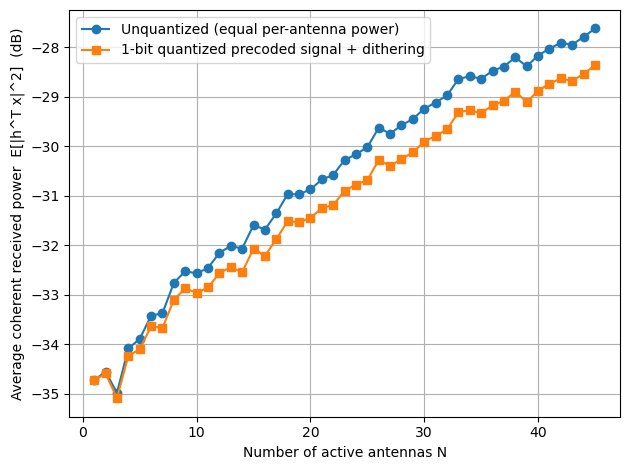

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def db2lin(db):
    return 10 ** (db / 10.0)


def lin2db(lin):
    return 10 * np.log10(lin + 1e-30)


def quantize_1bit_with_scaling(xd, N):
    """
    1-bit complex quantizer with scaling:
        Q(x) = sqrt(eta/2) * (sgn(Re{x}) + j sgn(Im{x}))
    with eta = 1/N to satisfy ||xq||^2 = 1.
    """
    eta = 1.0 / N
    scale = np.sqrt(eta / 2.0)

    re = np.sign(np.real(xd))
    im = np.sign(np.imag(xd))

    # avoid zeros: sign(0)=0 -> map to +1
    re[re == 0] = 1.0
    im[im == 0] = 1.0

    xq = scale * (re + 1j * im)
    return xq


def generate_fixed_antennas_45(rng, n_ant=45, area_side=50.0, z_ant=2.0):
    xy = rng.uniform(-area_side / 2, area_side / 2, size=(n_ant, 2))
    z = np.full((n_ant, 1), z_ant)
    return np.hstack([xy, z])  # (n_ant,3)


def sample_user_position(rng, area_side=50.0, z_user=0.0):
    x, y = rng.uniform(-area_side / 2, area_side / 2, size=2)
    return np.array([x, y, z_user])


def large_scale_fading_beta(d3d, alpha=3.0, d0=1.0, shadow_std_db=0.0, rng=None):
    d = np.maximum(d3d, d0)
    pl = (d0 / d) ** alpha
    if shadow_std_db > 0:
        assert rng is not None
        shadow_db = rng.normal(0.0, shadow_std_db, size=d.shape)
        pl = pl * db2lin(-shadow_db)
    return pl


def simulate_coherent_power_vs_N(
    seed=1,
    n_ant_total=45,
    area_side=50.0,
    z_ant=2.0,
    z_user=0.0,
    alpha=3.0,
    shadow_std_db=0.0,
    mc_user=2000,
    mc_small=1,
    mc_dither=1,
    rho_tx=1.0,
    sigma2_dither=0.1,
    use_constant_envelope_unquantized=True
):
    rng = np.random.default_rng(seed)

    # Fixed antenna positions (45 antennas)
    ant_pos_all = generate_fixed_antennas_45(
        rng=rng, n_ant=n_ant_total, area_side=area_side, z_ant=z_ant
    )

    N_list = np.arange(1, n_ant_total + 1)
    P_unquant = np.zeros(n_ant_total, dtype=np.float64)
    P_1bit = np.zeros(n_ant_total, dtype=np.float64)

    for mc_u in range(mc_user):
        user_pos = sample_user_position(rng=rng, area_side=area_side, z_user=z_user)

        diff = ant_pos_all - user_pos[None, :]
        d3d = np.linalg.norm(diff, axis=1)

        beta_all = large_scale_fading_beta(
            d3d=d3d, alpha=alpha, d0=1.0, shadow_std_db=shadow_std_db, rng=rng
        )

        for N in N_list:
            beta = beta_all[:N]

            pu_acc = 0.0
            pq_acc = 0.0

            for mc_s in range(mc_small):
                g = (rng.normal(0, 1, N) + 1j * rng.normal(0, 1, N)) / np.sqrt(2.0)
                h = np.sqrt(beta) * g

                # (A) Unquantized: equal per-antenna power, phase-only alignment
                if use_constant_envelope_unquantized:
                    x = (1.0 / np.sqrt(N)) * np.exp(-1j * np.angle(h))
                else:
                    x = np.conj(h)
                    x = x / (np.linalg.norm(x) + 1e-12)

                y0 = np.sqrt(rho_tx) * np.dot(h, x)
                pu_acc += np.abs(y0) ** 2

                # (B) 1-bit DAC: add dithering then 1-bit quantize
                for mc_d in range(mc_dither):
                    d = np.sqrt(sigma2_dither / 2.0) * (
                        rng.normal(0, 1, N) + 1j * rng.normal(0, 1, N)
                    )
                    xd = x + d
                    xq = quantize_1bit_with_scaling(xd, N=N)

                    yq0 = np.sqrt(rho_tx) * np.dot(h, xq)
                    pq_acc += np.abs(yq0) ** 2

            P_unquant[N - 1] += pu_acc / max(1, mc_small)
            P_1bit[N - 1] += pq_acc / max(1, mc_small * mc_dither)

    P_unquant /= mc_user
    P_1bit /= mc_user

    return N_list, P_unquant, P_1bit


if __name__ == "__main__":
    params = dict(
        seed=7,
        n_ant_total=45,
        area_side=80.0,
        z_ant=2.0,
        z_user=0.0,
        alpha=3.2,
        shadow_std_db=0.0,
        mc_user=2000,
        mc_small=1,
        mc_dither=1,
        rho_tx=1.0,
        sigma2_dither=0,
    )

    N_list, P_unq, P_q = simulate_coherent_power_vs_N(**params)

    plt.figure()
    plt.plot(N_list, lin2db(P_unq), marker="o", linewidth=1.5,
             label="Unquantized (equal per-antenna power)")
    plt.plot(N_list, lin2db(P_q), marker="s", linewidth=1.5,
             label="1-bit quantized precoded signal + dithering")

    plt.xlabel("Number of active antennas N")
    plt.ylabel("Average coherent received power  E[|h^T x|^2]  (dB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


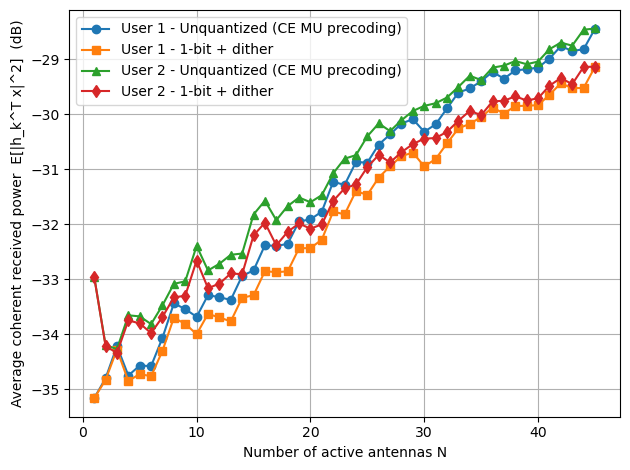

In [9]:
import numpy as np
import matplotlib.pyplot as plt


def lin2db(x):
    return 10 * np.log10(x + 1e-30)


def quantize_1bit_with_scaling(xd, N):
    """
    1-bit complex DAC quantizer:
        xq = sqrt(eta/2) * (sgn(Re{xd}) + j sgn(Im{xd}))
    with eta = 1/N so that ||xq||^2 = 1.
    """
    eta = 1.0 / N
    scale = np.sqrt(eta / 2.0)
    re = np.sign(np.real(xd))
    im = np.sign(np.imag(xd))
    re[re == 0] = 1.0
    im[im == 0] = 1.0
    return scale * (re + 1j * im)


def generate_fixed_antennas(rng, n_ant=45, area_side=80.0, z_ant=2.0):
    xy = rng.uniform(-area_side / 2, area_side / 2, size=(n_ant, 2))
    z = np.full((n_ant, 1), z_ant)
    return np.hstack([xy, z])


def sample_user_positions_2(rng, area_side=80.0, z_user=0.0, min_sep=5.0):
    """
    Sample 2 users on ground, enforce a minimum separation (meters)
    to avoid degenerate near-identical channels.
    """
    while True:
        u1 = np.array([*rng.uniform(-area_side/2, area_side/2, size=2), z_user])
        u2 = np.array([*rng.uniform(-area_side/2, area_side/2, size=2), z_user])
        if np.linalg.norm(u1[:2] - u2[:2]) >= min_sep:
            return u1, u2


def large_scale_beta(d3d, alpha=3.2, d0=1.0, shadow_std_db=0.0, rng=None):
    d = np.maximum(d3d, d0)
    beta = (d0 / d) ** alpha
    if shadow_std_db > 0:
        assert rng is not None
        sh_db = rng.normal(0.0, shadow_std_db, size=d.shape)
        beta = beta * (10 ** (-sh_db / 10.0))
    return beta


def constant_envelope_mu_precoder(h_list, weights=None):
    """
    Multi-user constant-envelope precoding (phase-only):
      v = sum_k w_k * conj(h_k)
      x = (1/sqrt(N)) * exp( j * angle(v) )
    This enforces equal per-antenna power (|x_n| = 1/sqrt(N)).
    """
    K = len(h_list)
    N = h_list[0].shape[0]
    if weights is None:
        weights = np.ones(K, dtype=np.float64)

    v = np.zeros(N, dtype=np.complex128)
    for k in range(K):
        v += weights[k] * np.conj(h_list[k])

    # avoid all-zero (extremely unlikely)
    if np.allclose(v, 0):
        v = np.conj(h_list[0])

    x = (1.0 / np.sqrt(N)) * np.exp(1j * np.angle(v))
    return x


def simulate_2user_four_curves(
    seed=7,
    n_ant_total=45,
    area_side=80.0,
    z_ant=2.0,
    z_user=0.0,
    alpha=3.2,
    shadow_std_db=0.0,
    mc_userpos=2000,     # MC over random user locations (your main MC)
    mc_small=1,          # small-scale fading per user position
    mc_dither=1,         # dithering realizations
    sigma2_dither=0.10,
    rho_tx=1.0,
    min_user_sep=5.0,
    weights=(1.0, 1.0)   # relative priority for two users
):
    rng = np.random.default_rng(seed)
    ant_pos_all = generate_fixed_antennas(rng, n_ant=n_ant_total, area_side=area_side, z_ant=z_ant)

    N_list = np.arange(1, n_ant_total + 1)

    # Four curves in linear domain
    P1_unq = np.zeros(n_ant_total)
    P1_q = np.zeros(n_ant_total)
    P2_unq = np.zeros(n_ant_total)
    P2_q = np.zeros(n_ant_total)

    for _ in range(mc_userpos):
        u1_pos, u2_pos = sample_user_positions_2(rng, area_side=area_side, z_user=z_user, min_sep=min_user_sep)

        # Large-scale for both users to all antennas
        d1 = np.linalg.norm(ant_pos_all - u1_pos[None, :], axis=1)
        d2 = np.linalg.norm(ant_pos_all - u2_pos[None, :], axis=1)
        beta1_all = large_scale_beta(d1, alpha=alpha, shadow_std_db=shadow_std_db, rng=rng)
        beta2_all = large_scale_beta(d2, alpha=alpha, shadow_std_db=shadow_std_db, rng=rng)

        for N in N_list:
            beta1 = beta1_all[:N]
            beta2 = beta2_all[:N]

            p1u_acc = p1q_acc = 0.0
            p2u_acc = p2q_acc = 0.0

            for _s in range(mc_small):
                # small-scale
                g1 = (rng.normal(0, 1, N) + 1j * rng.normal(0, 1, N)) / np.sqrt(2.0)
                g2 = (rng.normal(0, 1, N) + 1j * rng.normal(0, 1, N)) / np.sqrt(2.0)
                h1 = np.sqrt(beta1) * g1
                h2 = np.sqrt(beta2) * g2

                # Unquantized constant-envelope MU precoder
                x = constant_envelope_mu_precoder([h1, h2], weights=np.array(weights))

                y1 = np.sqrt(rho_tx) * np.dot(h1, x)
                y2 = np.sqrt(rho_tx) * np.dot(h2, x)
                p1u_acc += np.abs(y1) ** 2
                p2u_acc += np.abs(y2) ** 2

                # Quantized+dither
                for _d in range(mc_dither):
                    d = np.sqrt(sigma2_dither / 2.0) * (rng.normal(0, 1, N) + 1j * rng.normal(0, 1, N))
                    xd = x + d
                    xq = quantize_1bit_with_scaling(xd, N)

                    y1q = np.sqrt(rho_tx) * np.dot(h1, xq)
                    y2q = np.sqrt(rho_tx) * np.dot(h2, xq)
                    p1q_acc += np.abs(y1q) ** 2
                    p2q_acc += np.abs(y2q) ** 2

            P1_unq[N - 1] += p1u_acc / max(1, mc_small)
            P2_unq[N - 1] += p2u_acc / max(1, mc_small)
            P1_q[N - 1] += p1q_acc / max(1, mc_small * mc_dither)
            P2_q[N - 1] += p2q_acc / max(1, mc_small * mc_dither)

    # average over user positions
    P1_unq /= mc_userpos
    P2_unq /= mc_userpos
    P1_q /= mc_userpos
    P2_q /= mc_userpos

    return N_list, P1_unq, P1_q, P2_unq, P2_q


if __name__ == "__main__":
    N_list, P1_unq, P1_q, P2_unq, P2_q = simulate_2user_four_curves(
        seed=7,
        n_ant_total=45,
        area_side=80.0,
        alpha=3.2,
        shadow_std_db=0.0,
        mc_userpos=2000,
        mc_small=1,
        mc_dither=1,
        sigma2_dither=0,
        rho_tx=1.0,
        min_user_sep=5.0,
        weights=(1.0, 1.0)
    )

    plt.figure()
    plt.plot(N_list, lin2db(P1_unq), marker="o", linewidth=1.5, label="User 1 - Unquantized (CE MU precoding)")
    plt.plot(N_list, lin2db(P1_q), marker="s", linewidth=1.5, label="User 1 - 1-bit + dither")
    plt.plot(N_list, lin2db(P2_unq), marker="^", linewidth=1.5, label="User 2 - Unquantized (CE MU precoding)")
    plt.plot(N_list, lin2db(P2_q), marker="d", linewidth=1.5, label="User 2 - 1-bit + dither")

    plt.xlabel("Number of active antennas N")
    plt.ylabel("Average coherent received power  E[|h_k^T x|^2]  (dB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


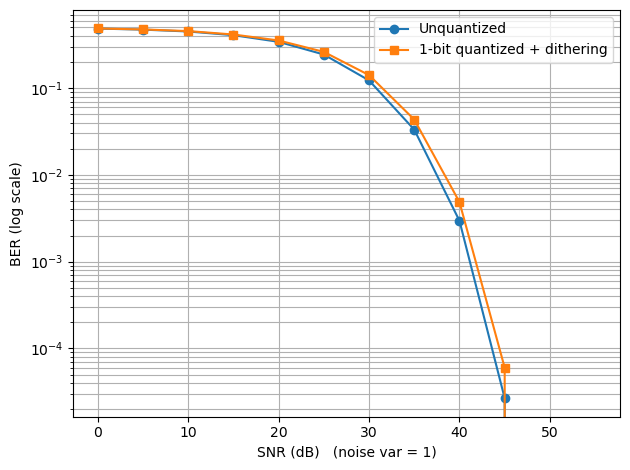

In [15]:
import numpy as np
import matplotlib.pyplot as plt


# -------------------------
# Utilities
# -------------------------

# -------------------------
# BPSK modulation / demodulation
# -------------------------
def bpsk_mod(bit):
    """
    bit: 0 or 1
    0 -> +1
    1 -> -1
    Unit-energy BPSK symbol.
    """
    return 1.0 if bit == 0 else -1.0


def bpsk_demod(s_hat):
    """
    Hard-decision BPSK demodulation.
    Decision on real part.
    """
    return 0 if np.real(s_hat) >= 0 else 1

def qpsk_mod(bits):
    """
    bits: shape (2, ) with {0,1}
    Gray mapping:
      00 -> +1 + j
      01 -> -1 + j
      11 -> -1 - j
      10 -> +1 - j
    normalized to unit energy: /sqrt(2)
    """
    b0, b1 = bits
    if (b0, b1) == (0, 0):
        s = 1 + 1j
    elif (b0, b1) == (0, 1):
        s = -1 + 1j
    elif (b0, b1) == (1, 1):
        s = -1 - 1j
    else:  # (1,0)
        s = 1 - 1j
    return s / np.sqrt(2)


def qpsk_demod(s_hat):
    """
    Hard decision QPSK (Gray)
    Returns bits (b0,b1).
    Decision by quadrant.
    """
    re = np.real(s_hat)
    im = np.imag(s_hat)
    # map quadrant back to bits following mod mapping above
    if re >= 0 and im >= 0:
        return np.array([0, 0], dtype=np.int8)  # + +
    elif re < 0 and im >= 0:
        return np.array([0, 1], dtype=np.int8)  # - +
    elif re < 0 and im < 0:
        return np.array([1, 1], dtype=np.int8)  # - -
    else:  # re>=0, im<0
        return np.array([1, 0], dtype=np.int8)  # + -


def quantize_1bit_with_scaling(xd, N):
    """
    Complex 1-bit DAC quantizer with power-normalizing scaling:
        xq = sqrt(eta/2) * (sgn(Re{xd}) + j sgn(Im{xd}))
    Choose eta = 1/N so that ||xq||^2 = 1 (total TX power normalized).
    """
    eta = 1.0 / N
    scale = np.sqrt(eta / 2.0)

    re = np.sign(np.real(xd))
    im = np.sign(np.imag(xd))
    # avoid zeros (np.sign(0)=0) -> map to +1
    re[re == 0] = 1.0
    im[im == 0] = 1.0

    return scale * (re + 1j * im)


def generate_fixed_antennas(rng, n_ant=45, area_side=80.0, z_ant=2.0):
    """
    Fixed distributed antennas on plane z=z_ant.
    """
    xy = rng.uniform(-area_side / 2, area_side / 2, size=(n_ant, 2))
    z = np.full((n_ant, 1), z_ant)
    return np.hstack([xy, z])  # (n_ant,3)


def sample_user_position(rng, area_side=80.0, z_user=0.0):
    x, y = rng.uniform(-area_side / 2, area_side / 2, size=2)
    return np.array([x, y, z_user])


def large_scale_beta(d3d, alpha=3.2, d0=1.0, shadow_std_db=0.0, rng=None):
    """
    beta = (d0/d)^alpha * 10^(-X/10), X ~ N(0, shadow_std_db^2) in dB
    """
    d = np.maximum(d3d, d0)
    beta = (d0 / d) ** alpha
    if shadow_std_db > 0:
        assert rng is not None
        sh_db = rng.normal(0.0, shadow_std_db, size=d.shape)
        beta *= 10 ** (-sh_db / 10.0)
    return beta


# -------------------------
# Main BER simulation
# -------------------------
def simulate_ber_single_user_qpsk(
    seed=7,
    n_ant_total=45,
    N_use=45,               # active antennas (<=45)
    area_side=80.0,
    z_ant=2.0,
    z_user=0.0,
    alpha=3.2,
    shadow_std_db=0.0,
    snr_db_list=None,       # BER vs SNR
    mc_userpos=500,         # Monte Carlo over random user positions
    mc_small=1,             # small-scale fading realizations per user position
    n_syms=2000,            # QPSK symbols per (userpos, small-scale)
    sigma2_dither=0.10      # dithering variance (complex): d ~ CN(0, sigma2 I)
):
    """
    System:
      - single user, QPSK symbols s
      - constant-envelope phase-only precoding v = (1/sqrt(N)) * exp(-j angle(h))
      - unquantized TX: x = v * s
      - quantized TX:  xd = x + d,  xq = Q_1bit(xd)  (eta=1/N scaling)
      - received: y = sqrt(rho) * h^T x + n, n ~ CN(0,1)

    Detection:
      - Unquantized: perfect equalization using a = sqrt(rho) * h^T v  (since y=a*s+n)
      - Quantized:  uses "oracle" effective a = sqrt(rho) * (h^T xq)/s for each symbol
                    (upper bound; for realistic receiver, replace with Bussgang-based a)
    """
    rng = np.random.default_rng(seed)

    if snr_db_list is None:
        snr_db_list = np.arange(-5, 21, 2)  # default -5..20 dB

    snr_db_list = np.array(snr_db_list, dtype=np.float64)
    rho_list = 10 ** (snr_db_list / 10.0)  # noise variance is 1

    # fixed antennas (45)
    ant_pos_all = generate_fixed_antennas(rng, n_ant=n_ant_total, area_side=area_side, z_ant=z_ant)
    assert 1 <= N_use <= n_ant_total

    ber_unq = np.zeros_like(rho_list)
    ber_q = np.zeros_like(rho_list)

    total_bits = 0

    for mc_u in range(mc_userpos):
        user_pos = sample_user_position(rng, area_side=area_side, z_user=z_user)

        # distances to antennas
        diff = ant_pos_all[:N_use] - user_pos[None, :]
        d3d = np.linalg.norm(diff, axis=1)

        beta = large_scale_beta(d3d, alpha=alpha, shadow_std_db=shadow_std_db, rng=rng)

        for mc_s in range(mc_small):
            # small-scale Rayleigh
            g = (rng.normal(0, 1, N_use) + 1j * rng.normal(0, 1, N_use)) / np.sqrt(2.0)
            h = np.sqrt(beta) * g  # (N,)

            # constant-envelope phase-only precoder vector v (unit norm, equal per-antenna power)
            v = (1.0 / np.sqrt(N_use)) * np.exp(-1j * np.angle(h))

            # generate QPSK symbols
            bits = rng.integers(0, 2, size=(n_syms, 2), dtype=np.int8)
            s_vec = np.array([qpsk_mod(bits[i]) for i in range(n_syms)], dtype=np.complex128)

            # bits = rng.integers(0, 2, size=n_syms, dtype=np.int8)
            # s_vec = np.array([bpsk_mod(bits[i]) for i in range(n_syms)])

            # precoded (unquantized) transmit vectors for all symbols: x[:,i] = v*s_i
            # We won't store huge matrix; compute per symbol.
            for i in range(n_syms):
                s = s_vec[i]

                # per-antenna equal power
                x = v * s  # (N,)

                # dithering
                d = np.sqrt(sigma2_dither / 2.0) * (rng.normal(0, 1, N_use) + 1j * rng.normal(0, 1, N_use))
                xd = x + d
                xq = quantize_1bit_with_scaling(xd, N_use)

                # For each SNR point, transmit through scalar channel and detect
                for idx, rho in enumerate(rho_list):
                    n = (rng.normal(0, 1) + 1j * rng.normal(0, 1)) / np.sqrt(2.0)  # CN(0,1)

                    # ---------- Unquantized ----------
                    y_unq = np.sqrt(rho) * np.dot(h, x) + n
                    a_unq = np.sqrt(rho) * np.dot(h, v)  # since x=v*s
                    s_hat_unq = y_unq / (a_unq + 1e-12)
                    bhat_unq = qpsk_demod(s_hat_unq)
                    ber_unq[idx] += np.sum(bhat_unq != bits[i])

                    # bhat_unq = bpsk_demod(s_hat_unq)
                    # ber_unq[idx] += (bhat_unq != bits[i])
                    # ---------- Quantized ----------
                    y_q = np.sqrt(rho) * np.dot(h, xq) + n
                    # oracle effective scalar a such that y ≈ a*s + n
                    a_q = np.sqrt(rho) * (np.dot(h, xq) / (s + 1e-12))
                    s_hat_q = y_q / (a_q + 1e-12)
                    bhat_q = qpsk_demod(s_hat_q)
                    ber_q[idx] += np.sum(bhat_q != bits[i])

                total_bits += 2  # QPSK = 2 bits per symbol

    ber_unq = ber_unq / total_bits
    ber_q = ber_q / total_bits

    return snr_db_list, ber_unq, ber_q


if __name__ == "__main__":
    snr_db, ber_unq, ber_q = simulate_ber_single_user_qpsk(
        seed=7,
        n_ant_total=45,
        N_use=45,            # change this if you want, e.g., 8/16/32/45
        area_side=80.0,
        z_ant=2.0,
        z_user=0.0,
        alpha=3.2,
        shadow_std_db=0.0,
        snr_db_list=np.arange(0, 59, 5),
        mc_userpos=50,      # increase for smoother curve
        mc_small=1,
        n_syms=1500,
        sigma2_dither=0
    )

    plt.figure()
    plt.semilogy(snr_db, ber_unq, marker="o", linewidth=1.5, label="Unquantized")
    plt.semilogy(snr_db, ber_q, marker="s", linewidth=1.5, label="1-bit quantized + dithering")

    plt.xlabel("SNR (dB)   (noise var = 1)")
    plt.ylabel("BER (log scale)")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()
